# FMP_seisbench
##### Sacha Lapins and Cindy Lim
Last updated 9th March 2026.
___
  
In this notebook, we demonstrate how to run the Seisbench implementation of the First Motion Polarity Determination model by Ross, Meier and Hauksson, 2018, JGR, available here: https://doi.org/10.1029/2017JB015251.

___
If you find the code, data or results in this notebook useful, please consider citing the archived version of this repository (Zenodo), and the original paper by Ross, Meier and Hauksson (2018).

A list of package dependencies for the Python environment to run this notebook is available here: https://github.com/cindylimsy/First_Motion_Polarity/blob/main/FMP_seisbench_requirements.txt

If you have any suggestions for improvements, issues with the code or notice any errors then feel free to contact me ([cindy.lim@bristol.ac.uk](mailto:cindy.lim@bristol.ac.uk)) or Sacha ([sacha.lapins@earth.ox.ac.uk](mailto:sacha.lapins@earth.ox.ac.uk)).

In [1]:
## Import modules
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import glob

import torch
import seisbench
import obspy
import obspy.core as oc
from obspy.clients.fdsn import Client
from obspy import UTCDateTime

# set all fontsize to 22
plt.rcParams.update({'font.size': 22})

In [2]:
# Import model and weights
from fmp_seisbench import FM_model
model = FM_model(component="Z") # Use Z component for polarities
fm_state_dict = torch.load('./original.pt')
model.load_state_dict(fm_state_dict)
model.eval() # Set to eval mode

FM_model(
  (conv1): Conv1d(1, 32, kernel_size=(21,), stride=(1,), padding=(10,))
  (bn1): BatchNorm1d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv1d(32, 64, kernel_size=(15,), stride=(1,), padding=(7,))
  (bn2): BatchNorm1d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv1d(64, 128, kernel_size=(11,), stride=(1,), padding=(5,))
  (bn3): BatchNorm1d(128, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=6400, out_features=512, bias=True)
  (bn4): BatchNorm1d(512, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=512, out_features=512, bias=True)
  (bn5): BatchNorm1d(512, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=512, out_features=3, bias=True)
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)

# Example 1

In [ ]:
# uploading data and picktimes from client
client = Client(base_url="https://webservices.ingv.it")  # choosing data from INGV client

inv = client.get_events(eventid=2457559,
                        includearrivals=True
                        )

onset_map = {
    "impulsive": "I",
    "emergent": "E",
    "questionable": "Q"
}

polarity_map = {
    "positive": "U",       # up
    "negative": "D",       # down
    "undecidable": None
}

rows = []

for pick in inv[0].picks:
    rows.append({
        "station": pick.waveform_id.station_code,
        "phase": pick.phase_hint,
        "impulsive-emergent": onset_map.get(pick.onset),
        "polarity": polarity_map.get(pick.polarity),
        "time": pick.time
    })

pick_times = pd.DataFrame(rows)

In [4]:
# get the P pick times
pick_times = pick_times.loc[pick_times['phase'] == "P"]
pick_times

,station,phase,impulsive-emergent,polarity,time
0,T0104,P,I,U,2011-11-28T18:56:51.490000Z
1,TERO,P,Q,None,2011-11-28T18:56:51.590000Z
2,AQU,P,Q,None,2011-11-28T18:56:51.800000Z
3,FIAM,P,I,U,2011-11-28T18:56:53.130000Z
4,FDMO,P,I,U,2011-11-28T18:56:55.580000Z
8,OFFI,P,I,U,2011-11-28T18:56:56.150000Z
9,TRTR,P,Q,None,2011-11-28T18:56:57.190000Z
11,CERT,P,Q,None,2011-11-28T18:56:58.610000Z
12,INTR,P,Q,None,2011-11-28T18:56:59.390000Z
13,CING,P,Q,None,2011-11-28T18:57:01.010000Z


In [5]:
# Get waveforms for all 70 stations (can take about 2 minutes to download the data)
client = Client(base_url="https://webservices.ingv.it") # choosing data from INGV
st = client.get_waveforms(network="IV", 
                          station=','.join(list(pick_times.station)), 
                          starttime=obspy.UTCDateTime("2011-11-28T18:55:00"), 
                          endtime=obspy.UTCDateTime("2011-11-28T19:00:00"), 
                          location="*", 
                          channel="HHZ,HNZ,EHZ" # Vertical component - same sensor types as paper
                          )
st.merge()
st

33 Trace(s) in Stream:

IV.ARCI..HHZ | 2011-11-28T18:55:00.000000Z - 2011-11-28T19:00:00.000000Z | 100.0 Hz, 30001 samples
...
(31 other traces)
...
IV.VAGA..HNZ | 2011-11-28T18:55:00.000000Z - 2011-11-28T19:00:00.000000Z | 100.0 Hz, 30001 samples

[Use "print(Stream.__str__(extended=True))" to print all Traces]

In [6]:
# showing function to populate the picktimes dataframe 
model.classify_mean_sliding_window?

Signature:
model.classify_mean_sliding_window(
    stream,
    picktimes,
    time_win=0.25,
    ignore_unknown=True,
    ignore_unknown_warning_thresh=0.2,
    min_class_accept_ratio=3,
    plot=False,
)
Docstring:
Function to populate the picktimes dataframe with the mean probabilities of all classes (U,D,K) 
for the +-250 sample window, the final polarity class label and its corresponding probability.

Input: 
    stream = steam of continuous data (>= 500 samples),
    picktimes = dataframe containing 'station' columns and 'time' columns (P picktimes in UTCDateTime format)
    time_win = time window around the pick, set at 0.25 seconds default (+-0.25 seconds = 0.5 seconds window)
    ignore_unknown = option to force a label instead of the "Unknown" class
    ignore_unknown_warning_thresh = threshold to ignore the unknown class, if not, a warning is flagged for future user decision
    min_class_accept_ratio = minimum accept ratio between the Up and Down class probabilities 
    plo

In [7]:
# applying the classify_mean_sliding_window function (can take up to 30s)
picktimes_labelled = model.classify_mean_sliding_window(st, pick_times)

Station missing traces: AQU
Station missing traces: ROTM


In [8]:
picktimes_labelled

,station,phase,impulsive-emergent,polarity,time,mean_probabilities_of_classes,mean_polarity_class,mean_polarity_probability,prediction_warning
0,T0104,P,I,U,2011-11-28T18:56:51.490000Z,"[0.96943307, 0.009848001, 0.020718949]",U,0.969433,False
1,TERO,P,Q,None,2011-11-28T18:56:51.590000Z,"[0.007340383, 0.9599048, 0.03275487]",D,0.959905,False
2,AQU,P,Q,None,2011-11-28T18:56:51.800000Z,None,NaN,NaN,False
3,FIAM,P,I,U,2011-11-28T18:56:53.130000Z,"[0.9329592, 0.012242552, 0.054798294]",U,0.932959,False
4,FDMO,P,I,U,2011-11-28T18:56:55.580000Z,"[0.96111816, 0.014964679, 0.023917148]",U,0.961118,False
8,OFFI,P,I,U,2011-11-28T18:56:56.150000Z,"[0.9254524, 0.015929542, 0.058618017]",U,0.925452,False
9,TRTR,P,Q,None,2011-11-28T18:56:57.190000Z,"[0.842787, 0.02515768, 0.1320553]",U,0.842787,False
11,CERT,P,Q,None,2011-11-28T18:56:58.610000Z,"[0.37000993, 0.025479037, 0.6045111]",U,0.370010,False
12,INTR,P,Q,None,2011-11-28T18:56:59.390000Z,"[0.1127331, 0.053687334, 0.83357954]",U,0.112733,True
13,CING,P,Q,None,2011-11-28T18:57:01.010000Z,"[0.25140858, 0.047375336, 0.70121604]",U,0.251409,False


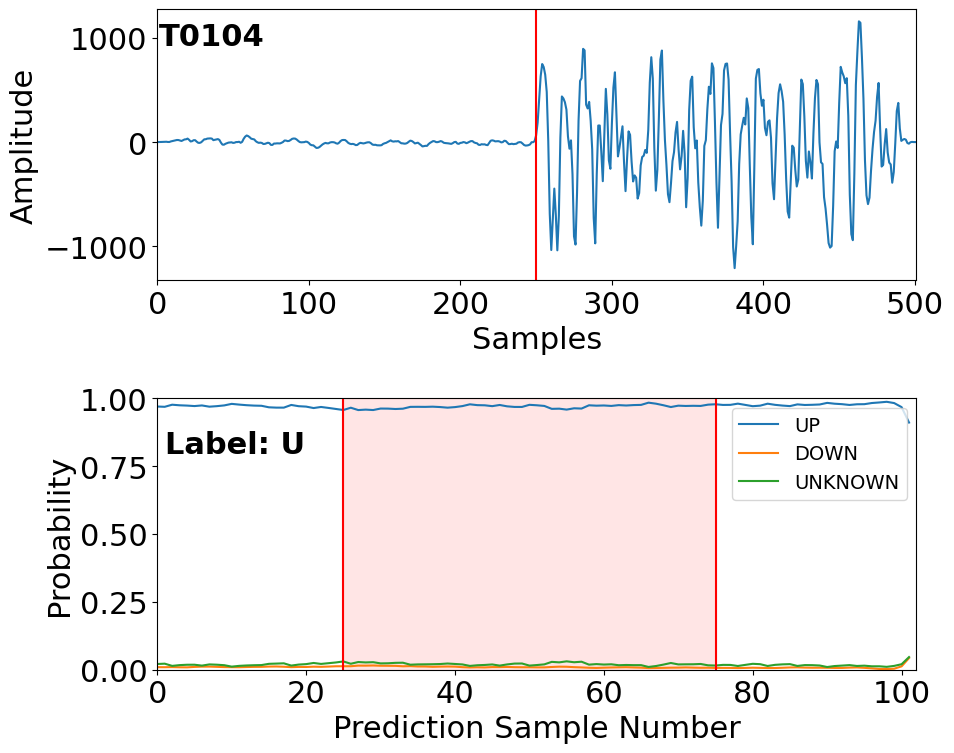

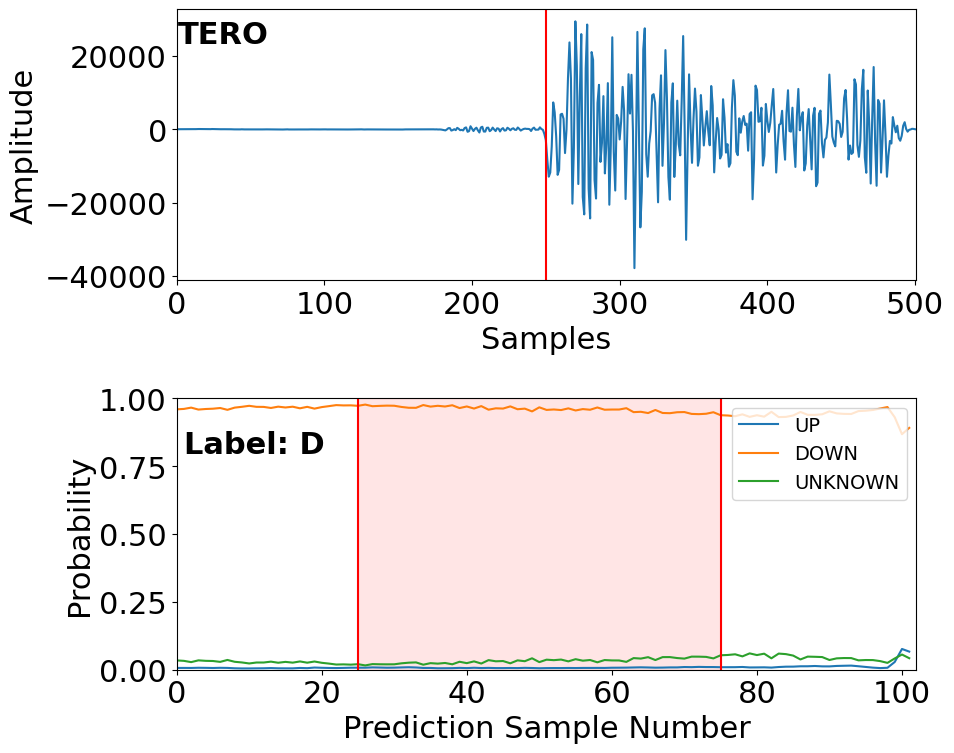

Station missing traces: AQU


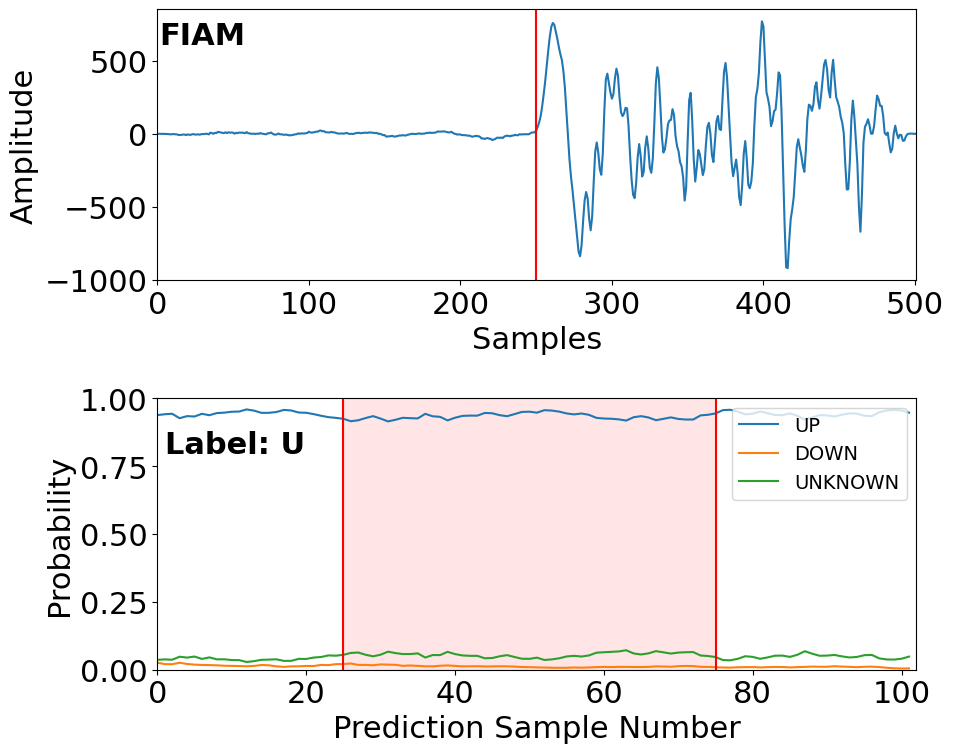

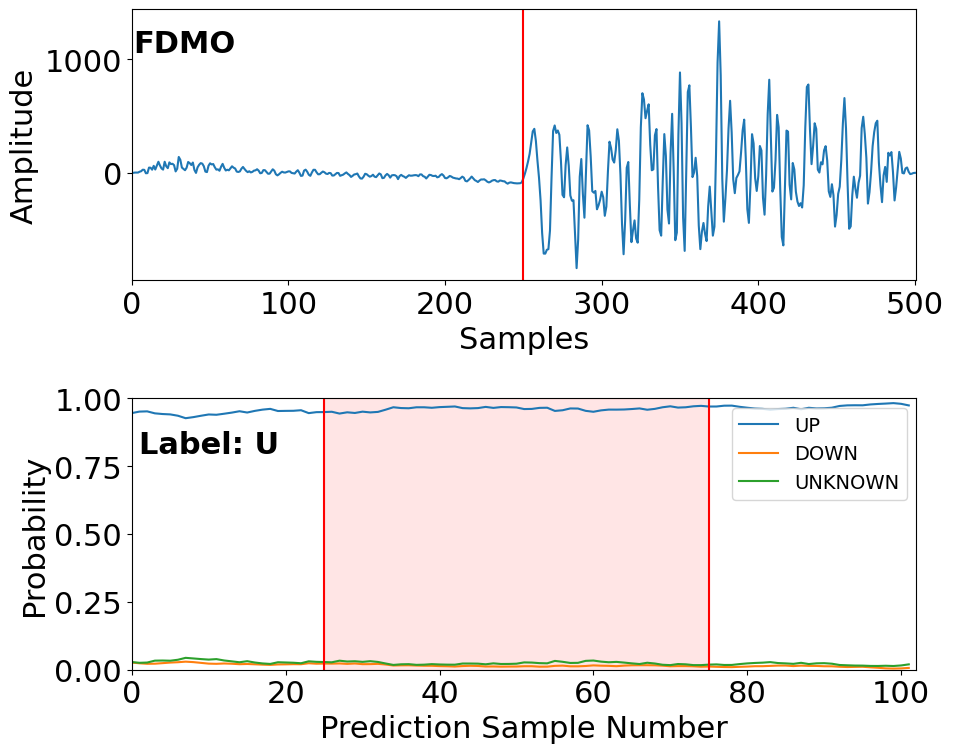

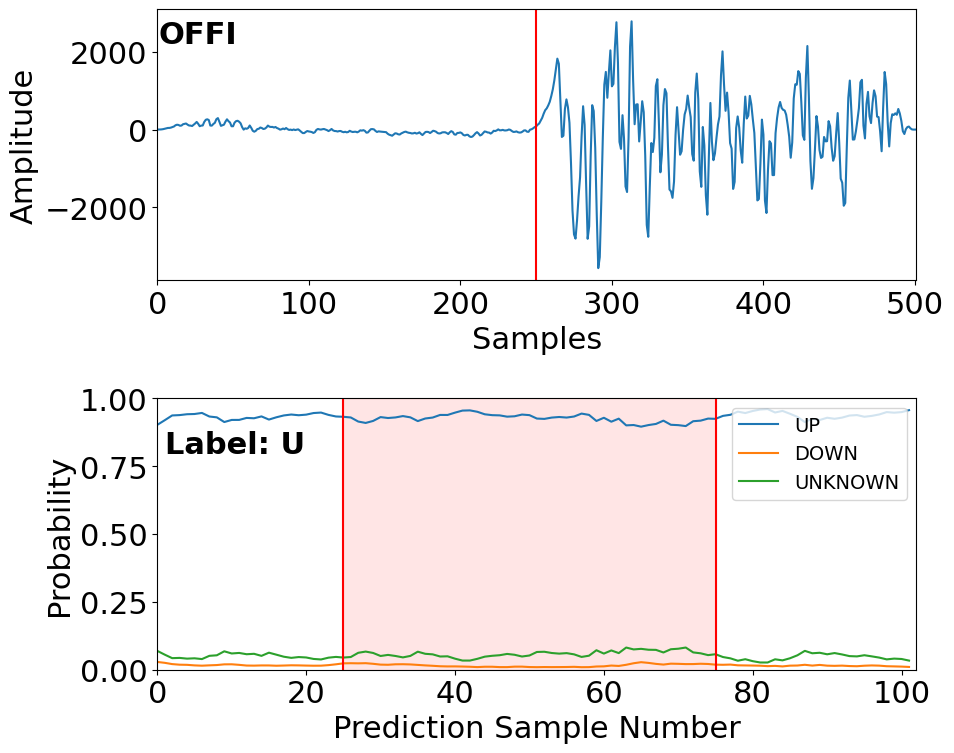

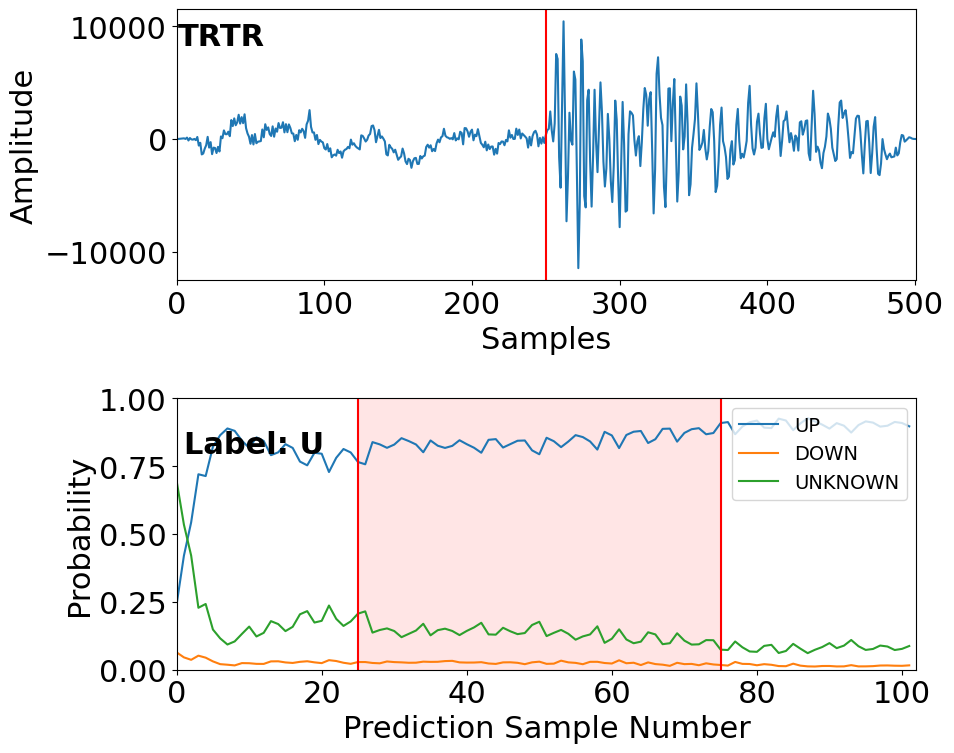

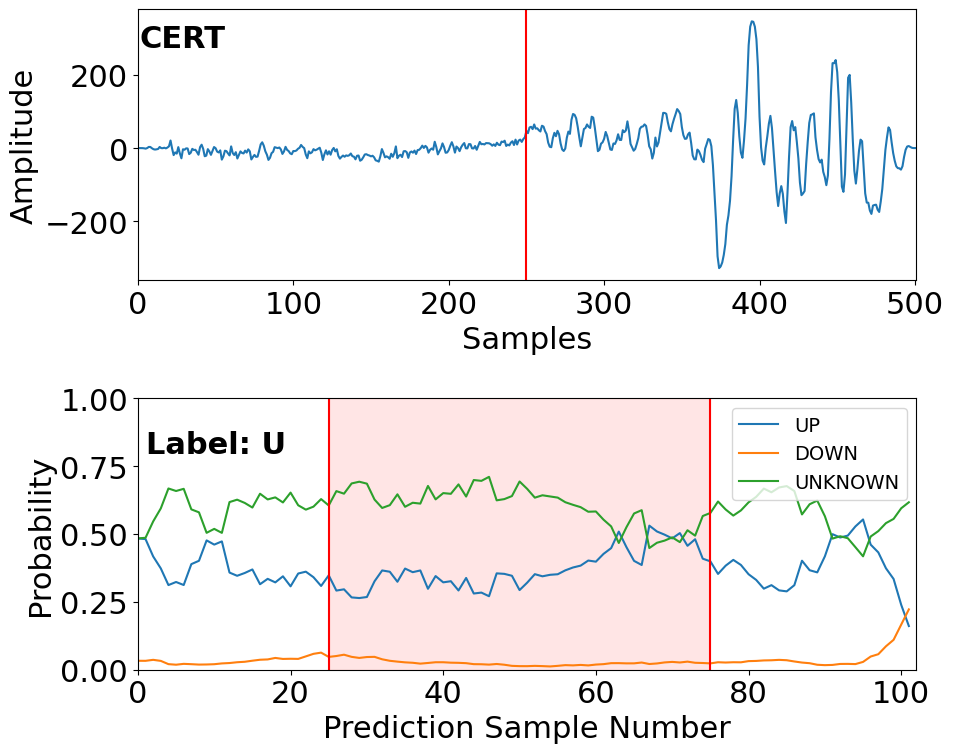

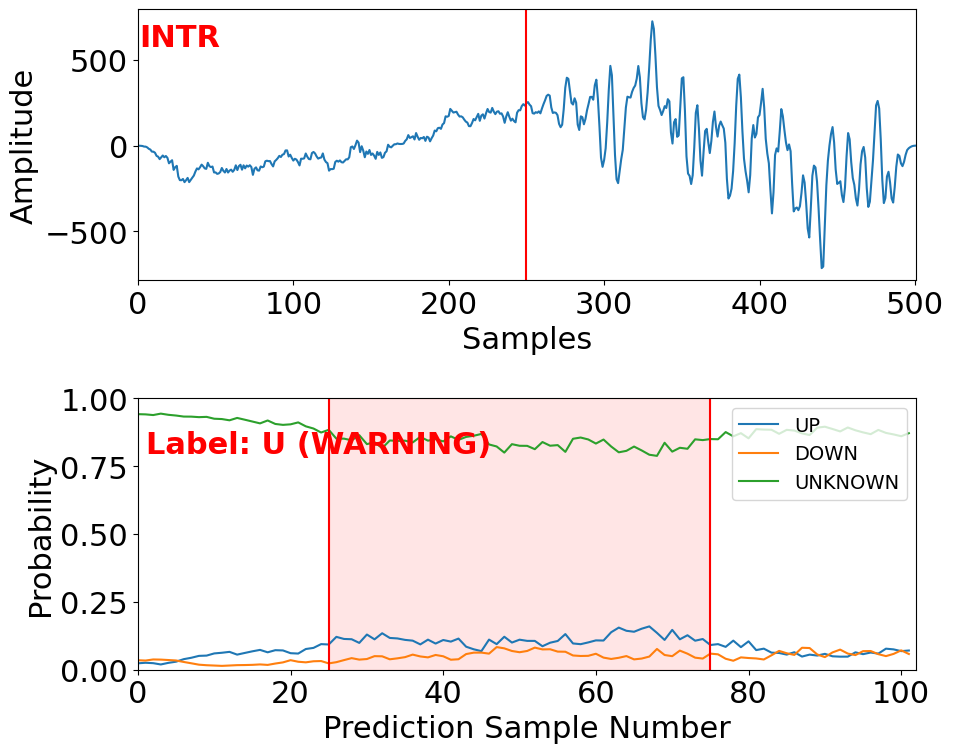

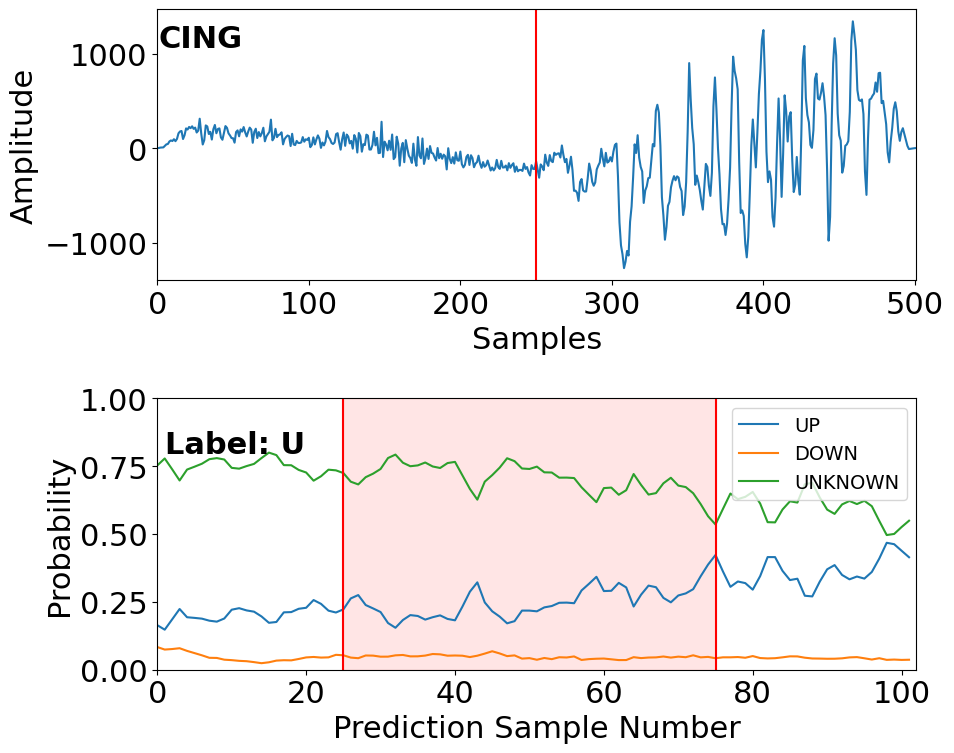

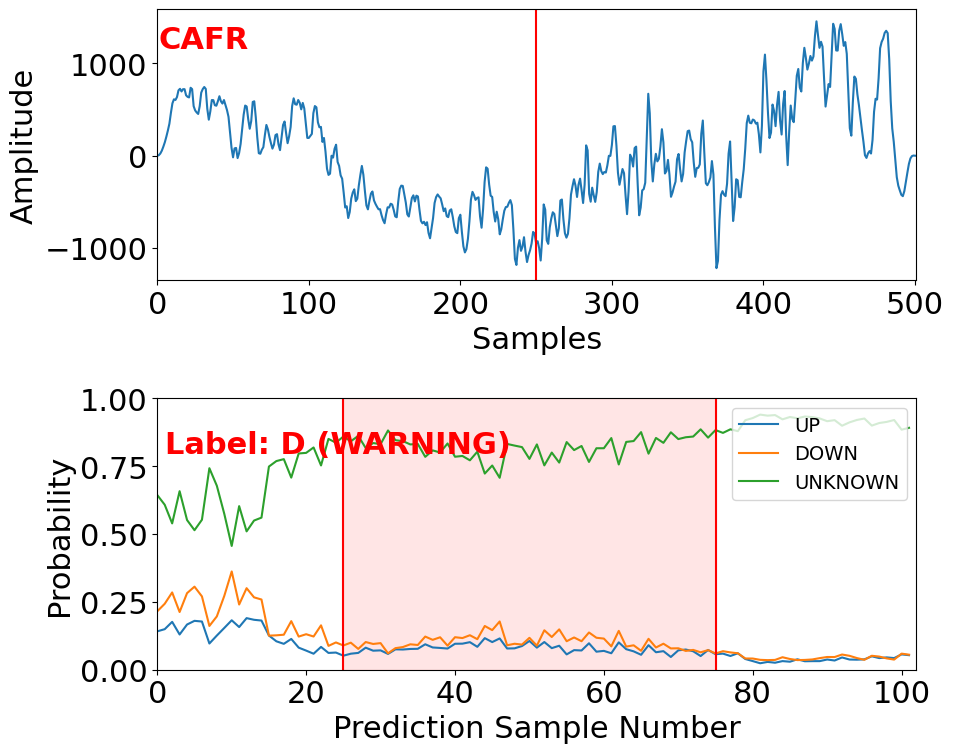

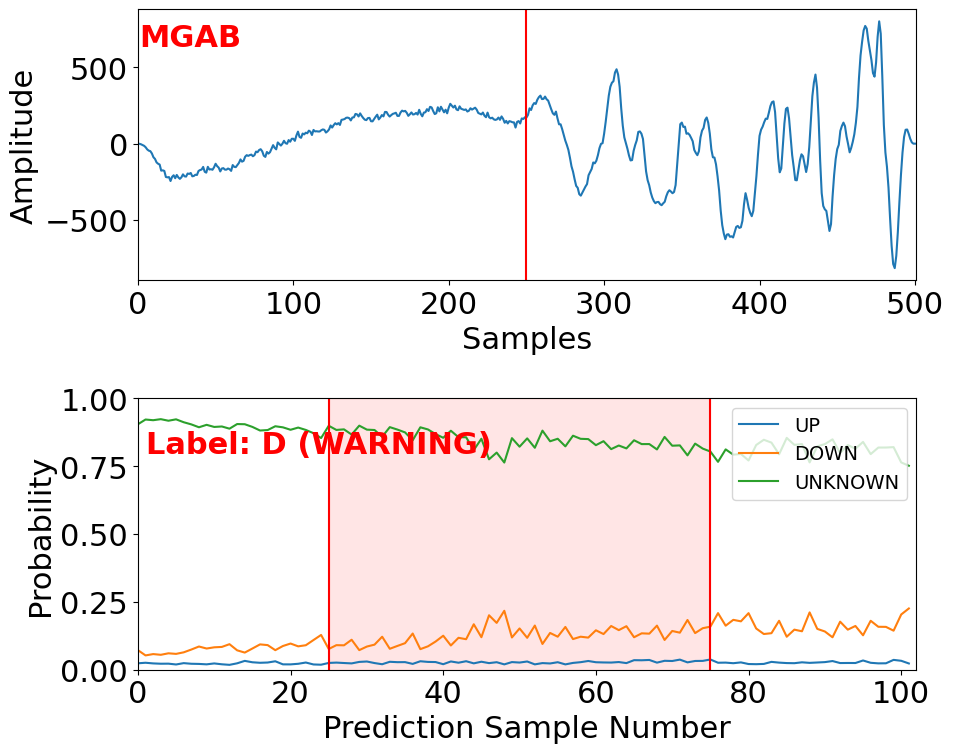

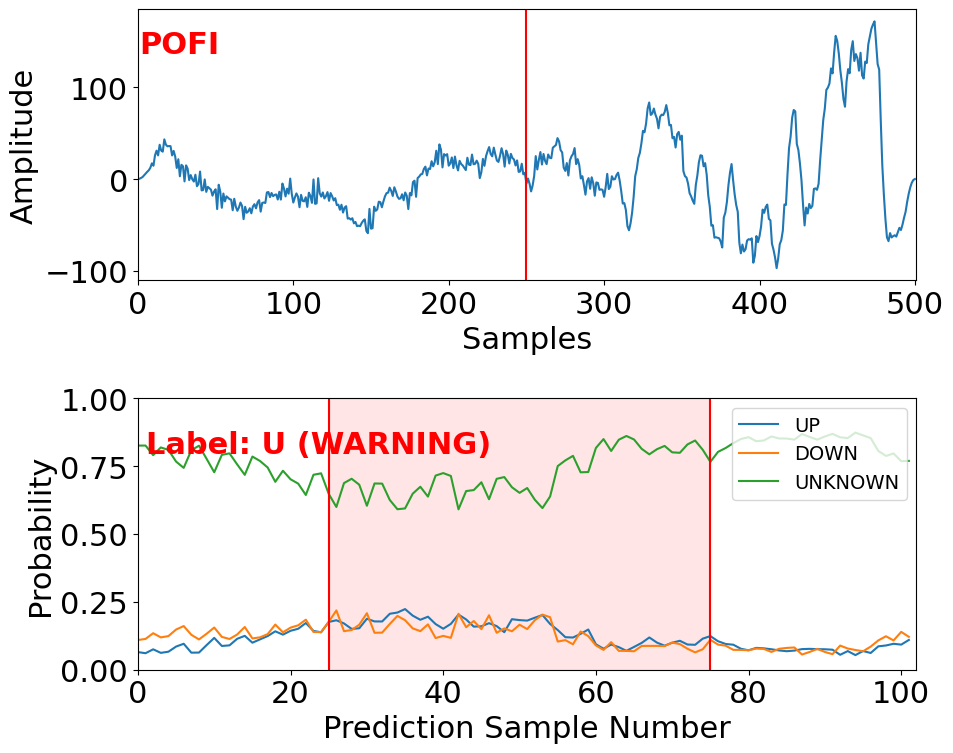

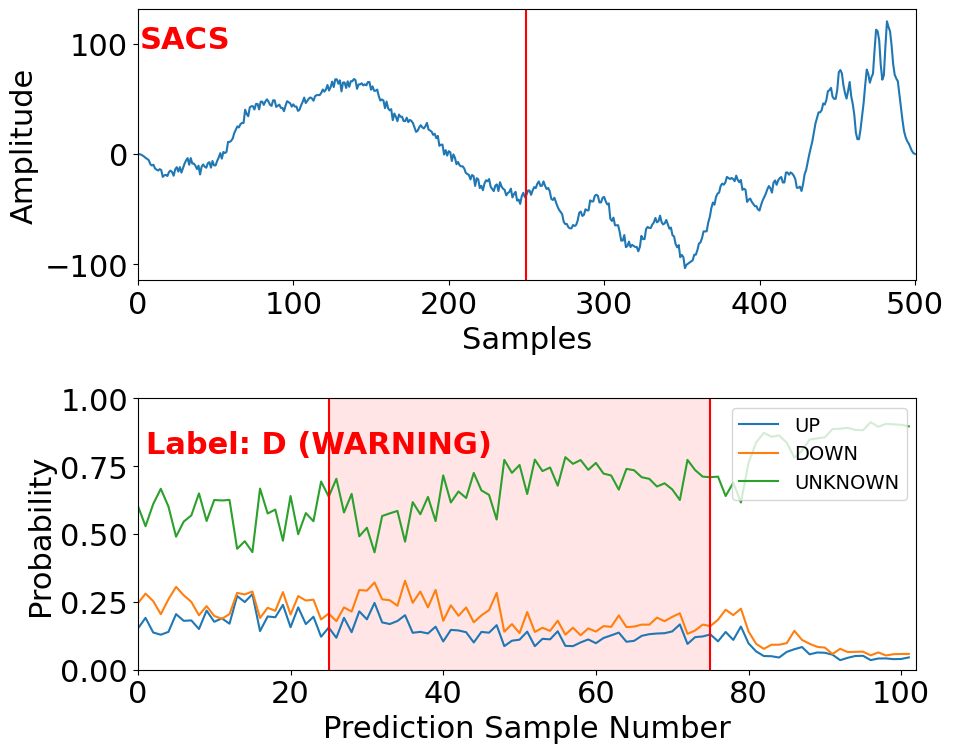

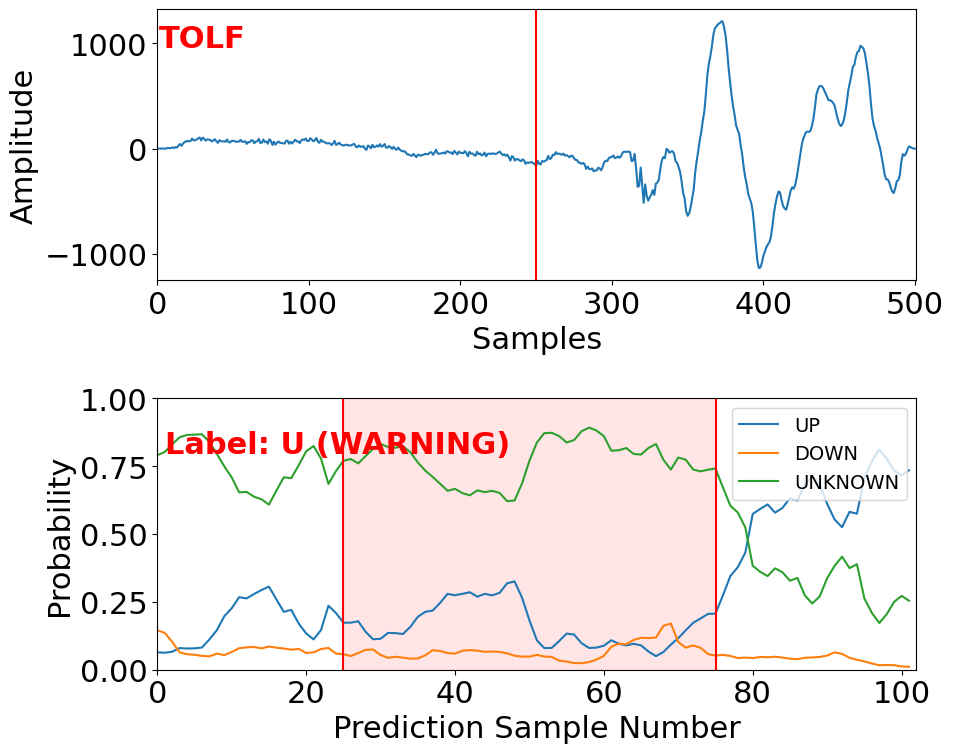

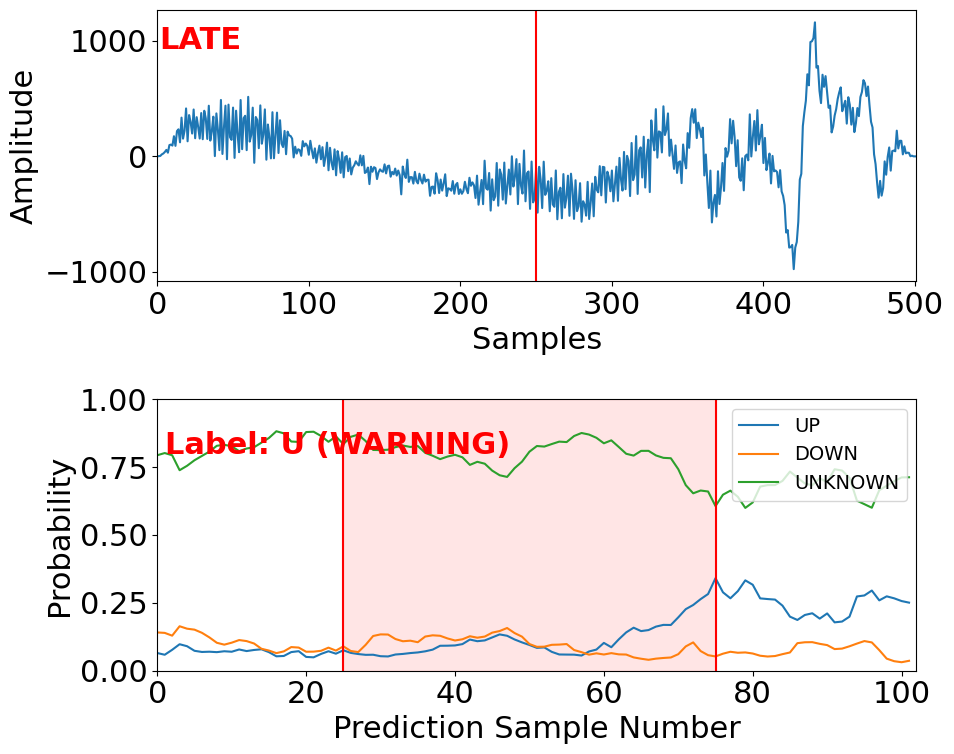

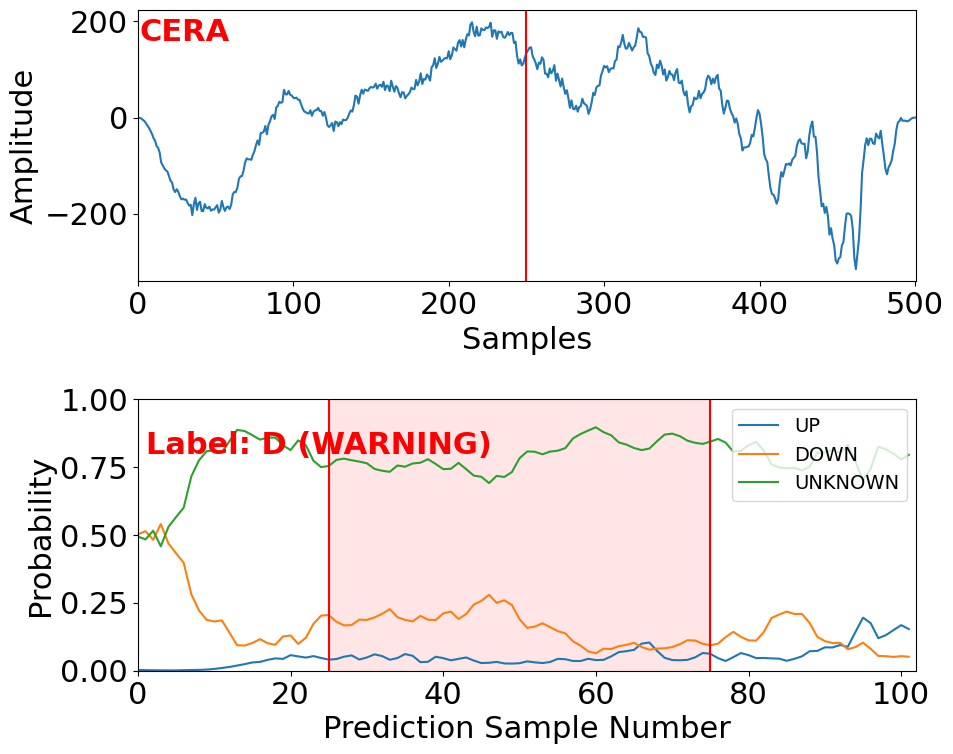

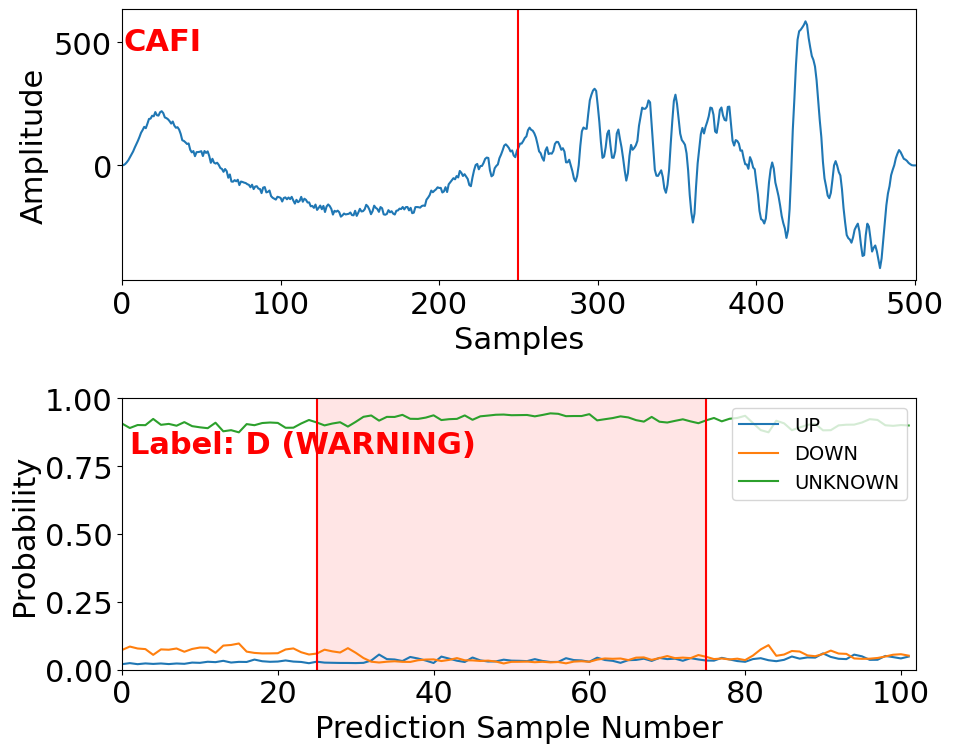

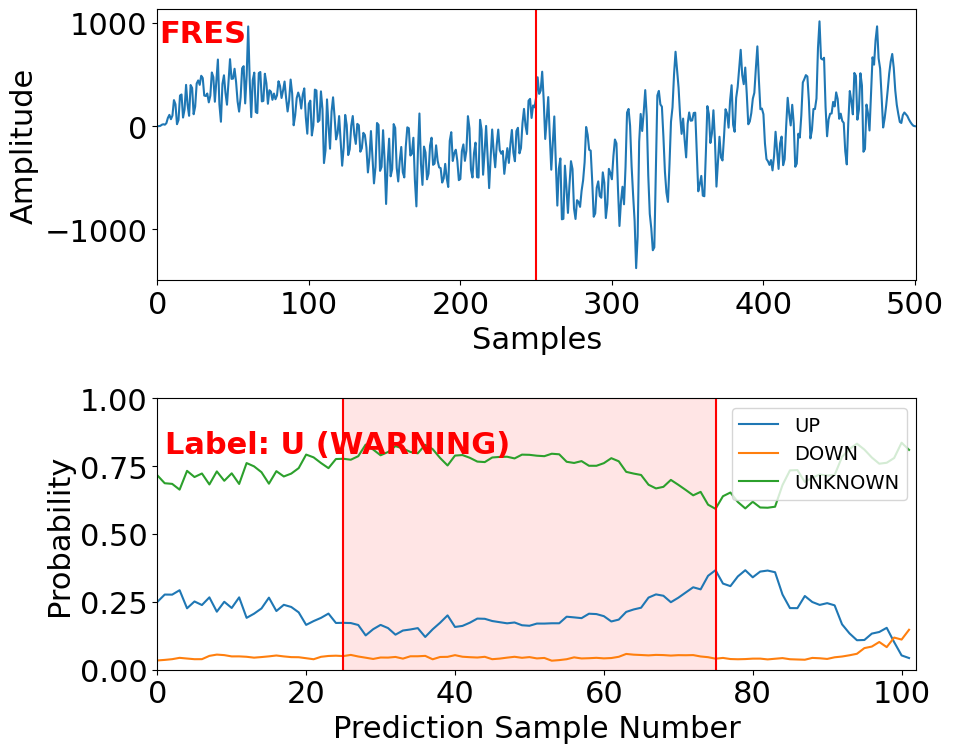

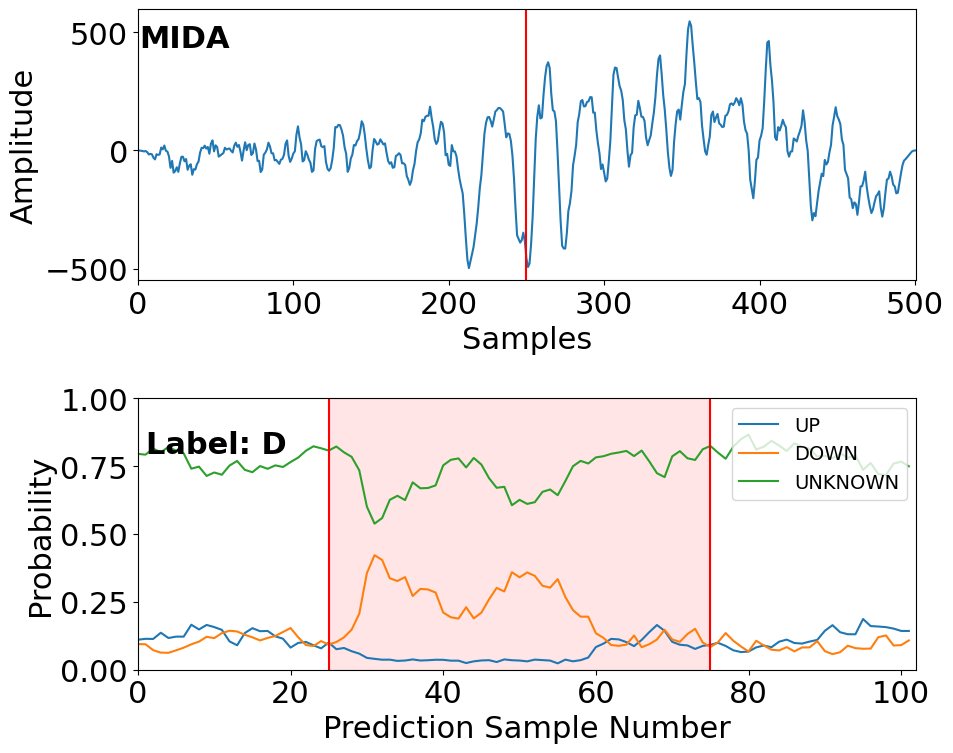

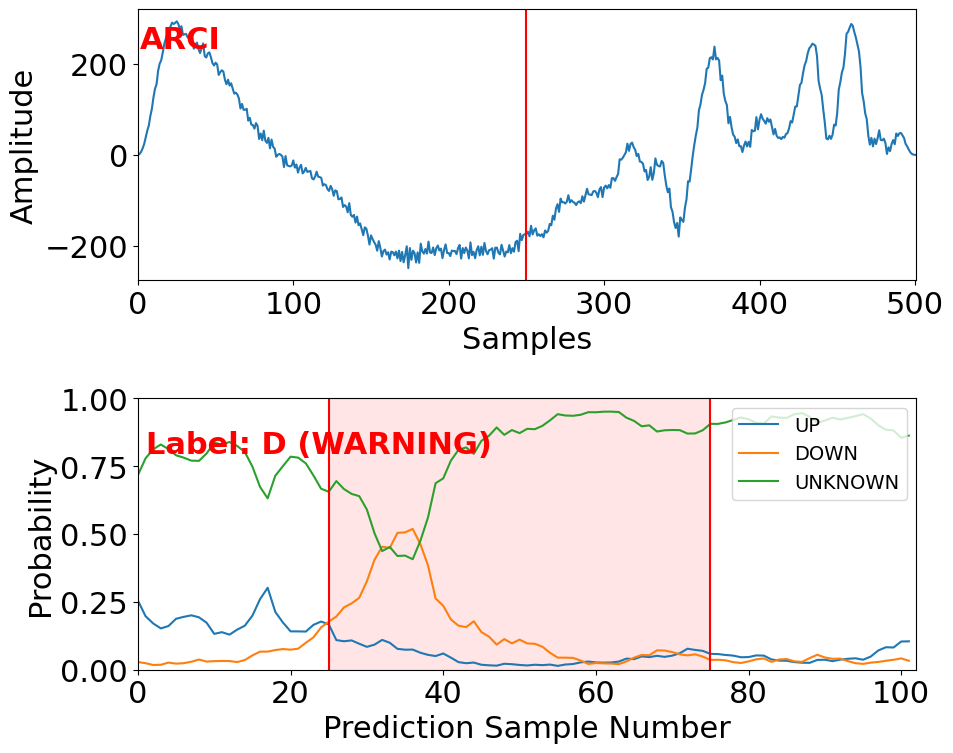

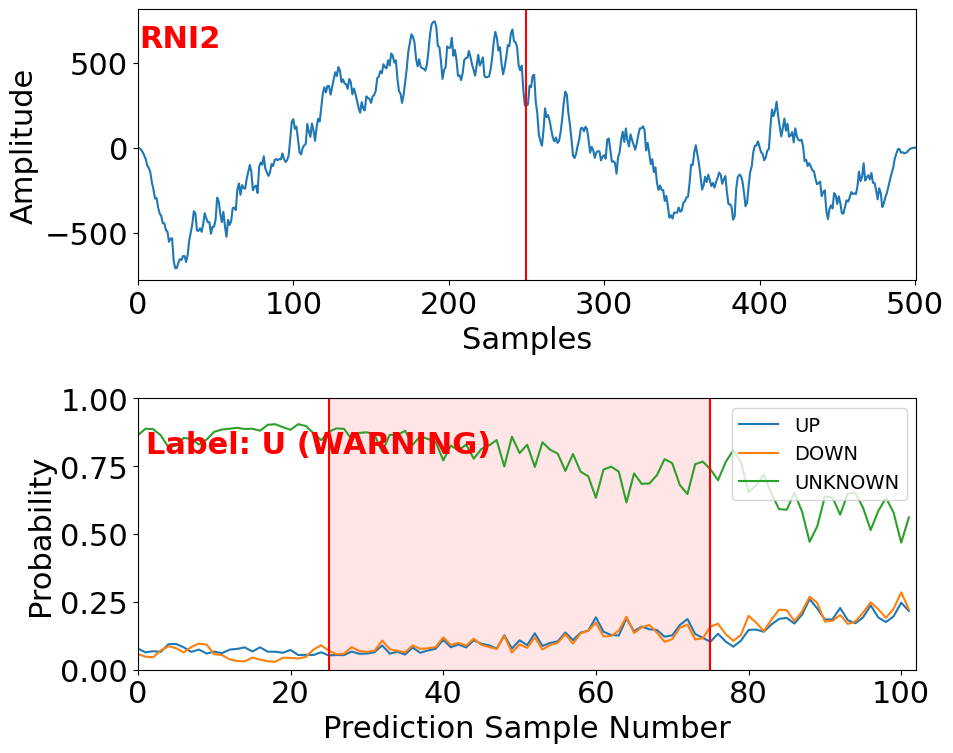

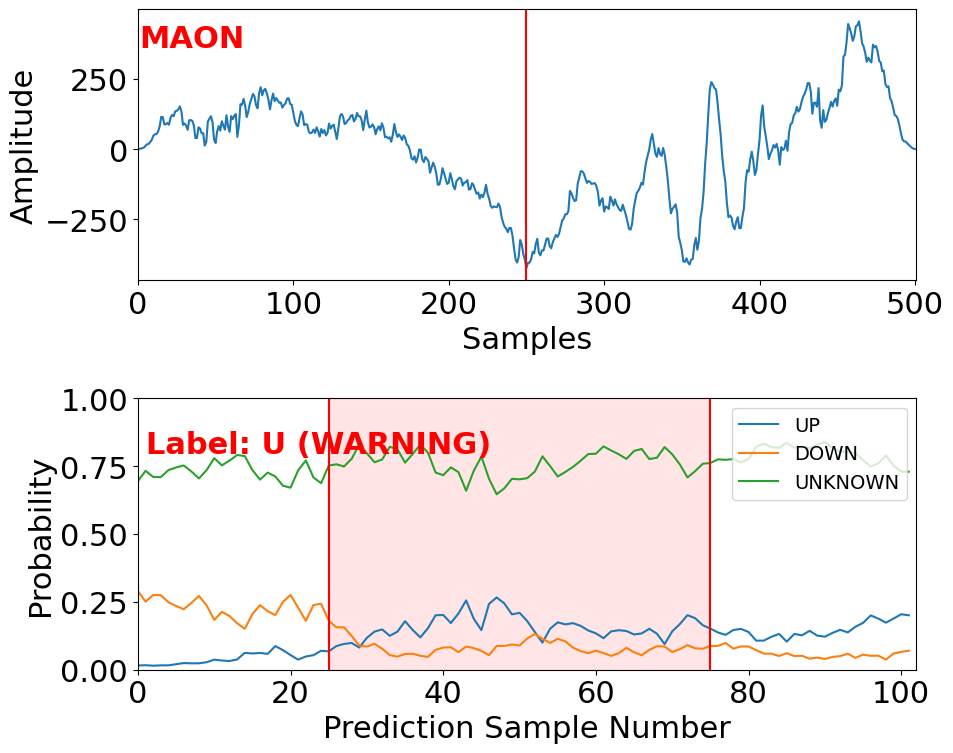

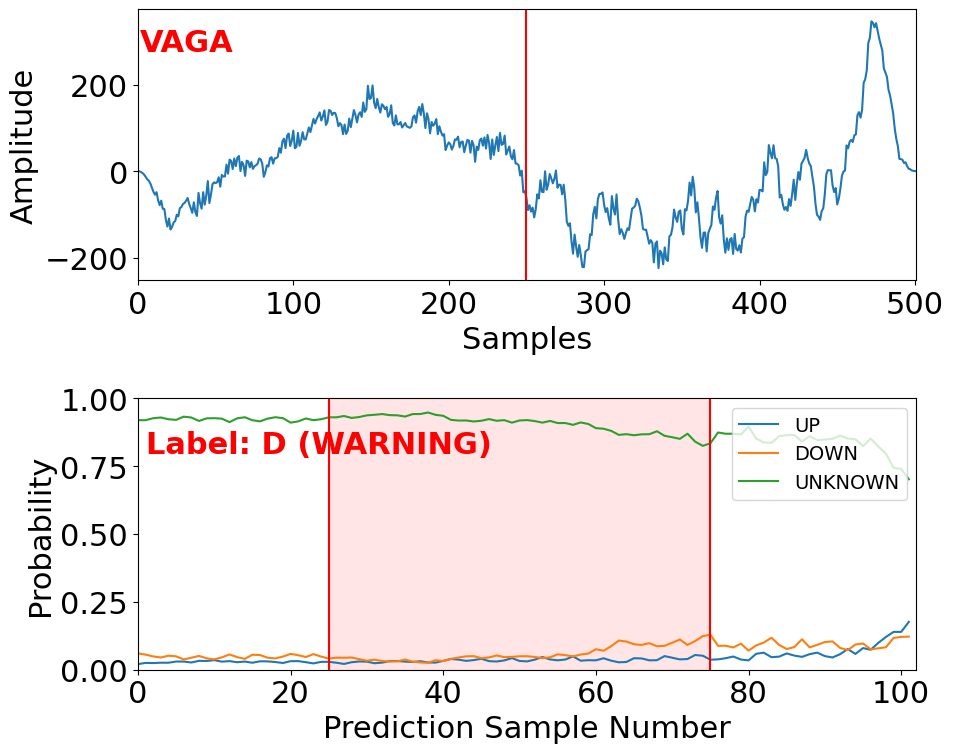

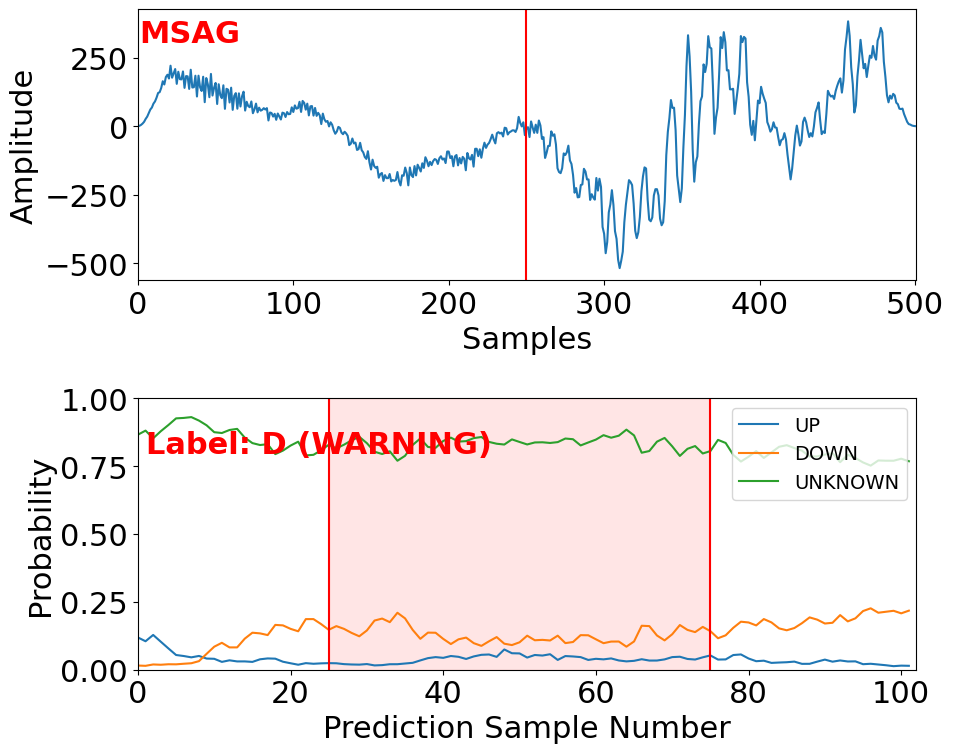

Station missing traces: ROTM


In [9]:
# show plots 
picktimes_labelled = model.classify_mean_sliding_window(st, pick_times, plot=True)

In [10]:
picktimes_labelled

,station,phase,impulsive-emergent,polarity,time,mean_probabilities_of_classes,mean_polarity_class,mean_polarity_probability,prediction_warning
0,T0104,P,I,U,2011-11-28T18:56:51.490000Z,"[0.96943307, 0.009848001, 0.020718949]",U,0.969433,False
1,TERO,P,Q,None,2011-11-28T18:56:51.590000Z,"[0.007340383, 0.9599048, 0.03275487]",D,0.959905,False
2,AQU,P,Q,None,2011-11-28T18:56:51.800000Z,None,NaN,NaN,False
3,FIAM,P,I,U,2011-11-28T18:56:53.130000Z,"[0.9329592, 0.012242552, 0.054798294]",U,0.932959,False
4,FDMO,P,I,U,2011-11-28T18:56:55.580000Z,"[0.96111816, 0.014964679, 0.023917148]",U,0.961118,False
8,OFFI,P,I,U,2011-11-28T18:56:56.150000Z,"[0.9254524, 0.015929542, 0.058618017]",U,0.925452,False
9,TRTR,P,Q,None,2011-11-28T18:56:57.190000Z,"[0.842787, 0.02515768, 0.1320553]",U,0.842787,False
11,CERT,P,Q,None,2011-11-28T18:56:58.610000Z,"[0.37000993, 0.025479037, 0.6045111]",U,0.370010,False
12,INTR,P,Q,None,2011-11-28T18:56:59.390000Z,"[0.1127331, 0.053687334, 0.83357954]",U,0.112733,True
13,CING,P,Q,None,2011-11-28T18:57:01.010000Z,"[0.25140858, 0.047375336, 0.70121604]",U,0.251409,False
